# 🧠 Word2Vec — Skip-gram, CBOW & Negative Sampling

**What this notebook covers:**
1. The core idea — learning from context (Distributional Hypothesis)
2. The two architectures: CBOW and Skip-gram
3. Skip-gram: sliding window, dataset creation, architecture
4. Why softmax over full vocabulary is too slow
5. Negative Sampling — the efficient training trick with full math
6. Step-by-step forward pass and weight update
7. Code: Build Word2Vec from scratch + use Gensim
8. Visualise word geometry — analogies and cosine similarity

**Pre-requisite:** `01_bow_tfidf.ipynb` (understanding what one-hot and BoW are)


In [1]:
import os
from PIL import Image

notebook_dir = os.path.abspath('')

## 1. 💡 The Core Idea — Learning from Context

### The Distributional Hypothesis
> "A word's meaning is defined by the words that surround it." — Firth (1957)

**Informal version:** Words used in similar contexts have similar meanings.

**Examples:**
- "The **cat** sat on the mat" and "The **dog** sat on the mat" → cat and dog appear in similar contexts → they should have similar vectors
- "She is a great **scientist**" and "She is a great **engineer**" → both words can follow "great" and relate to expertise
- "I ate a **banana**" and "I ate an **apple**" → both fit in food contexts

Word2Vec exploits this by **training a neural network to predict context words from a target word** (or vice versa). The learned weights become the word embeddings.

### What Word2Vec Actually Learns
Word2Vec does NOT directly try to learn "meaning". Instead, it trains a prediction task, and the **weights learned during training** turn out to capture meaning as a side effect.

This is a central insight: **good representations emerge from solving good prediction tasks on large amounts of data.**

### The Two Architectures
Word2Vec has two variants:

1. **CBOW (Continuous Bag of Words):** Given context words → predict the target word
   - *"I love [?] very much"* → predict "cats"
   - Faster to train, slightly better for frequent words

2. **Skip-gram:** Given target word → predict context words
   - *"cats"* → predict ["I", "love", "very", "much"]
   - Slower to train, better for rare words and large datasets
   - More commonly used and studied

We'll focus on **Skip-gram** as it's the more powerful and widely understood architecture.


## 2. 🪟 Skip-gram — Building the Training Dataset

### Step 1: Choose a Window Size
The **window size** $w$ determines how many words to the left and right of the target word are considered "context".

With window size $w = 2$:
```
Sentence: "I love cats very much"
                  ↑
              target word
Context: [words within 2 positions of target]
```

### Step 2: Slide the Window Across the Sentence

**Sentence:** "the quick brown fox jumps"

Let's trace through with window $w = 2$:

```
Position 0 — Target: "the"
  Context (right only, can't go left): "quick", "brown"
  Training pairs: (the, quick), (the, brown)

Position 1 — Target: "quick"
  Context: "the", "brown", "fox"
  Training pairs: (quick, the), (quick, brown), (quick, fox)

Position 2 — Target: "brown"
  Context: "the", "quick", "fox", "jumps"
  Training pairs: (brown, the), (brown, quick), (brown, fox), (brown, jumps)

Position 3 — Target: "fox"
  Context: "quick", "brown", "jumps"
  Training pairs: (fox, quick), (fox, brown), (fox, jumps)

Position 4 — Target: "jumps"
  Context: "brown", "fox"
  Training pairs: (jumps, brown), (jumps, fox)
```

**Summary of all (target, context) training pairs:**
```
(the, quick), (the, brown),
(quick, the), (quick, brown), (quick, fox),
(brown, the), (brown, quick), (brown, fox), (brown, jumps),
(fox, quick), (fox, brown), (fox, jumps),
(jumps, brown), (jumps, fox)
```

Each pair becomes one training example: "given the left word, predict the right word."

### The Task
For each (target, context) pair, train the network to answer:
- Input: target word vector
- Output: which word in the vocabulary is the context?

This creates an **enormous dataset** from raw text — no labels needed. This is **self-supervised learning**.


## 3. 🏗️ Skip-gram Architecture

### Neural Network Structure

Skip-gram is a **shallow neural network** with:
- **Input layer:** one-hot vector of the target word (size = vocab_size $V$)
- **Hidden layer:** $N$ neurons (the embedding dimension, e.g., $N=300$) — **no activation function**
- **Output layer:** $V$ neurons with Softmax (probability over entire vocabulary)


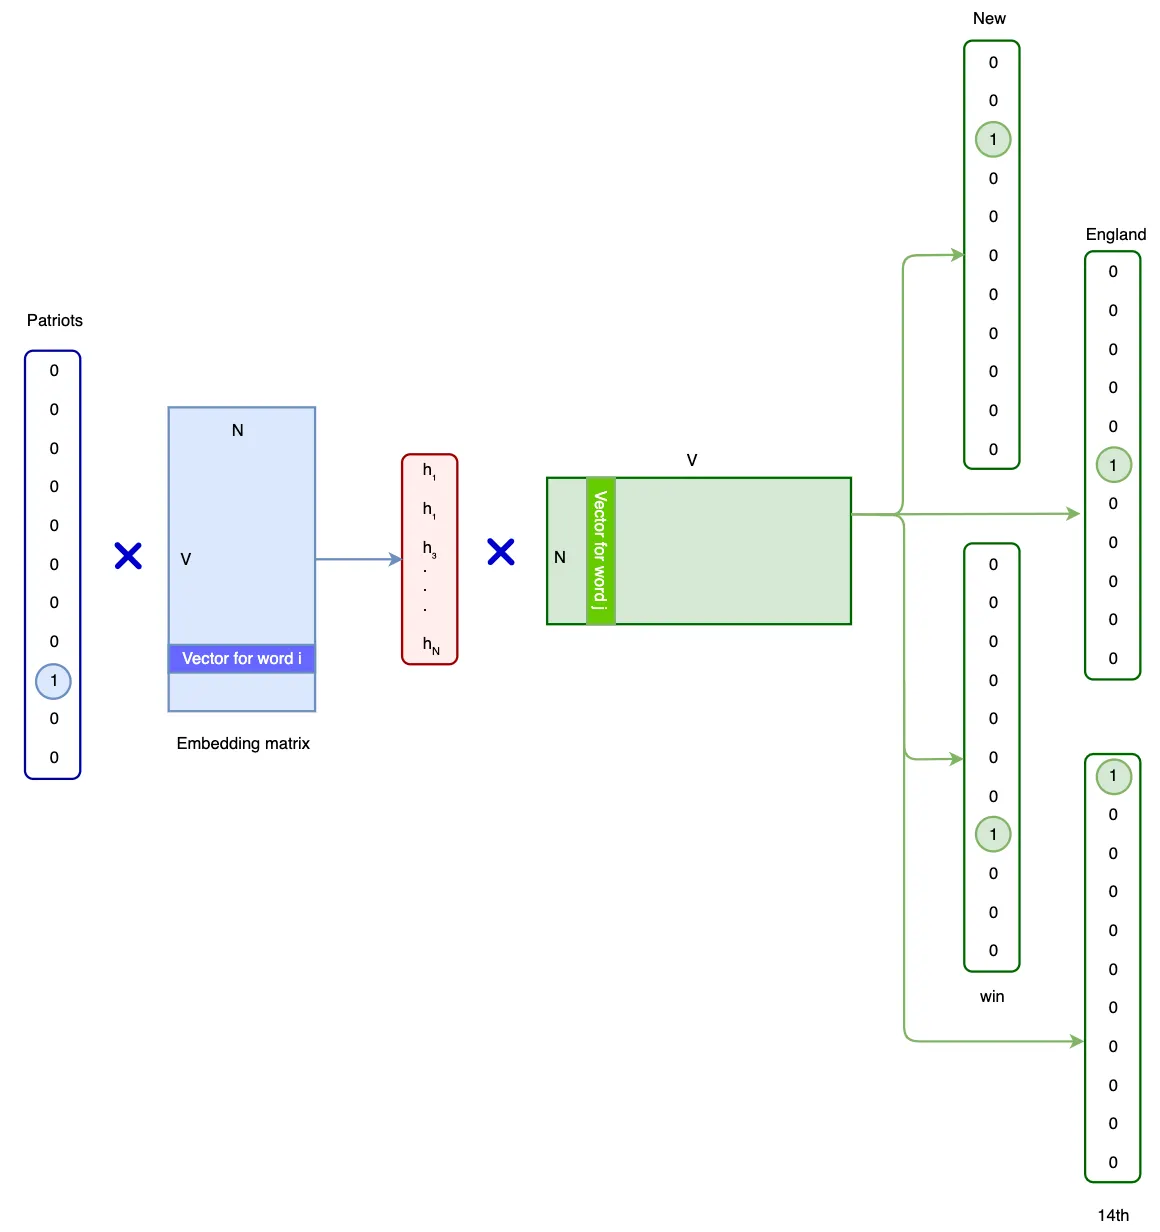

In [2]:
img_path = os.path.join(notebook_dir, r"assets\embeddings\skipgram.webp")

# Load and show
try:
    img = Image.open(img_path)
    display(img)
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}")

### Weight Matrices
There are two weight matrices:
- $W_{\text{in}}$ of shape $[N \times V]$: **input-to-hidden** (one embedding per word)
- $W_{\text{out}}$ of shape $[V \times N]$: **hidden-to-output** (one "context embedding" per word)

### Forward Pass

**Step 1 — Lookup embedding for target word:**
$$h = W_{\text{in}} \cdot x$$
where $x$ is the one-hot vector. Since $x$ is one-hot, this is just **selecting one column** of $W_{\text{in}}$ — the embedding of the target word.
$$h = W_{\text{in}}[:, \text{target\_idx}]$$

**Step 2 — Compute score for each vocabulary word:**
$$z = W_{\text{out}} \cdot h \quad \text{shape: } [V \times 1]$$
Each element $z_j$ is the dot product of the context embedding of word $j$ with the target embedding $h$.

**Step 3 — Softmax to get probabilities:**
$$P(w_j | w_{\text{target}}) = \frac{e^{z_j}}{\sum_{k=1}^{V} e^{z_k}}$$

**Step 4 — Loss (cross-entropy for one training pair):**
$$\mathcal{L} = -\log P(w_{\text{context}} | w_{\text{target}}) = -z_{\text{context}} + \log \sum_{k} e^{z_k}$$

### The Computational Problem
Computing $\sum_{k=1}^{V} e^{z_k}$ (the softmax denominator) requires going through ALL $V$ words in the vocabulary.

For $V = 50,000$ and millions of training pairs: this is **billions of operations**.  
Training would take months on a single machine.

**Solution: Negative Sampling** (next section).


## 4. ⚡ Negative Sampling — The Key Innovation

### The Reformulation
Instead of training the model to predict exactly which word is the context (a V-class classification), we reformulate the problem as **binary classification**:

**For each training pair (target, context):**
- Create 1 **positive example**: (target, context_word) → label = 1 (these two words ARE neighbours)
- Create $k$ **negative examples**: (target, random_word) → label = 0 (these are NOT neighbours)

We call $k$ the **number of negative samples** (typically $k = 5$ for large datasets, $k = 15$ for small ones).

### Objective Function

For a single positive pair (target $w$, context $c$) with $k$ negative samples $n_1, n_2, \ldots, n_k$:

$$\mathcal{L} = \log \sigma(v_c^\top h_w) + \sum_{i=1}^{k} \mathbb{E}_{n_i \sim P_{noise}} \left[ \log \sigma(-v_{n_i}^\top h_w) \right]$$

Where:
- $\sigma(x) = \frac{1}{1+e^{-x}}$ = the **sigmoid function** (logistic function)
- $v_c$ = context vector (row of $W_{\text{out}}$) for the real context word
- $v_{n_i}$ = context vector for negative sample $n_i$
- $h_w$ = embedding (row of $W_{\text{in}}$) for the target word

**First term:** $\log \sigma(v_c^\top h_w)$ — push the dot product between real target and real context **positive** (closer together)

**Second term:** $\sum \log \sigma(-v_{n_i}^\top h_w)$ — push the dot product between target and random (negative) words **negative** (further apart)

We **maximise** this objective (or equivalently, minimise its negative).

---

### The Noise Distribution $P_{noise}$
How do we sample negative words? Not uniformly at random (that would over-sample common words).

Word2Vec uses a **smoothed unigram distribution**:
$$P_{noise}(w) = \frac{f(w)^{0.75}}{\sum_{u} f(u)^{0.75}}$$

where $f(w)$ is the raw frequency of word $w$ in the corpus.

The exponent $0.75$ (between 0 and 1) **compresses the distribution** — making rare words slightly more likely to be sampled than their frequency alone would suggest, while still favouring more common words. This empirically gives better embeddings.

**Example:** If "cat" appears 100 times and "quantum" appears 1 time:
- Without smoothing: P(cat) ∝ 100, P(quantum) ∝ 1 → quantum rarely sampled
- With 0.75 smoothing: P(cat) ∝ 100^0.75 ≈ 31.6, P(quantum) ∝ 1^0.75 = 1 → quantum ~3× more likely

---

### Why Negative Sampling Works
Instead of computing softmax over 50,000 words, each training step only touches:
- The target word vector ($h_w$)
- The 1 real context word vector ($v_c$)
- The $k$ negative sample vectors ($v_{n_1}, \ldots, v_{n_k}$)

Total vectors touched per update: $1 + 1 + k$ instead of $V = 50,000$.  
For $k=5$: **7 vectors instead of 50,000** — a **7,000× speedup**.


## 5. 🔢 Step-by-Step Numerical Trace — One Training Update

Let's trace through a complete forward pass and weight update for Skip-gram with Negative Sampling.

**Setup:**
- Vocabulary: V = 5 words: ["the", "cat", "sat", "on", "mat"]
- Embedding dimension: N = 3
- Training pair: target = "cat" (idx=1), context = "sat" (idx=2)
- Negative samples: "the" (idx=0), "mat" (idx=4)
- Learning rate: η = 0.01

**Initial weights (random initialisation):**
```
W_in  (5×3):               W_out (5×3):
the  [-0.1,  0.2, -0.3]    the  [ 0.1, -0.1,  0.2]
cat  [ 0.4, -0.1,  0.2]    sat  [ 0.3,  0.2, -0.1]
sat  [-0.2,  0.3,  0.1]    on   [-0.2,  0.1,  0.3]
on   [ 0.1, -0.2,  0.4]    mat  [ 0.2, -0.3,  0.1]
mat  [-0.3,  0.1, -0.1]    cat  [-0.1,  0.2, -0.2]
```

### Step 1 — Lookup target embedding
$h = W_{\text{in}}[\text{"cat"}] = [0.4, -0.1, 0.2]$

### Step 2 — Compute scores (dot products)
**Positive pair (cat, sat):**
$$s_{+} = v_{\text{sat}}^\top \cdot h = [0.3, 0.2, -0.1] \cdot [0.4, -0.1, 0.2] = 0.12 - 0.02 - 0.02 = 0.08$$

**Negative sample 1 (cat, the):**
$$s_{n1} = v_{\text{the}}^\top \cdot h = [0.1, -0.1, 0.2] \cdot [0.4, -0.1, 0.2] = 0.04 + 0.01 + 0.04 = 0.09$$

**Negative sample 2 (cat, mat):**
$$s_{n2} = v_{\text{mat}}^\top \cdot h = [0.2, -0.3, 0.1] \cdot [0.4, -0.1, 0.2] = 0.08 + 0.03 + 0.02 = 0.13$$

### Step 3 — Apply sigmoid
$$\sigma(s_{+}) = \sigma(0.08) = \frac{1}{1+e^{-0.08}} \approx 0.520 \quad \text{(want this → 1)}$$
$$\sigma(s_{n1}) = \sigma(0.09) \approx 0.522 \quad \text{(want this → 0)}$$
$$\sigma(s_{n2}) = \sigma(0.13) \approx 0.532 \quad \text{(want this → 0)}$$

### Step 4 — Compute errors
$$e_{+} = \sigma(s_{+}) - 1 = 0.520 - 1 = -0.480 \quad \text{(positive: error = σ - 1)}$$
$$e_{n1} = \sigma(s_{n1}) - 0 = 0.522 \quad \text{(negative: error = σ - 0)}$$
$$e_{n2} = \sigma(s_{n2}) - 0 = 0.532$$

### Step 5 — Update output vectors
$$v_{\text{sat}} \mathrel{-}= \eta \cdot e_{+} \cdot h = v_{\text{sat}} - 0.01 \times (-0.480) \times [0.4,-0.1,0.2]$$
$$= [0.3,0.2,-0.1] + [0.00192, -0.00048, 0.00096] = [0.30192, 0.19952, -0.09904]$$

$$v_{\text{the}} \mathrel{-}= \eta \cdot e_{n1} \cdot h = [0.1,-0.1,0.2] - 0.01 \times 0.522 \times [0.4,-0.1,0.2]$$
$$= [0.1,-0.1,0.2] - [0.00209,-0.000522,0.001044] = [0.09791,-0.099478,0.198956]$$

### Step 6 — Update input (target) vector
The gradient for $h$ (target word "cat") accumulates errors from all pairs:
$$\nabla h = e_{+} \cdot v_{\text{sat}} + e_{n1} \cdot v_{\text{the}} + e_{n2} \cdot v_{\text{mat}}$$
$$= (-0.480)[0.3, 0.2,-0.1] + (0.522)[0.1,-0.1,0.2] + (0.532)[0.2,-0.3,0.1]$$

$$h_{\text{cat}} \mathrel{-}= \eta \cdot \nabla h$$

After enough such updates, "cat" and "sat" will have closer vectors (they co-occur), while "cat" and random words will be pushed apart.


gensim not found — using synthetic embeddings for visualisation


FileNotFoundError: [Errno 2] No such file or directory: 'llm_basic/assets/02_w2v_geometry.png'

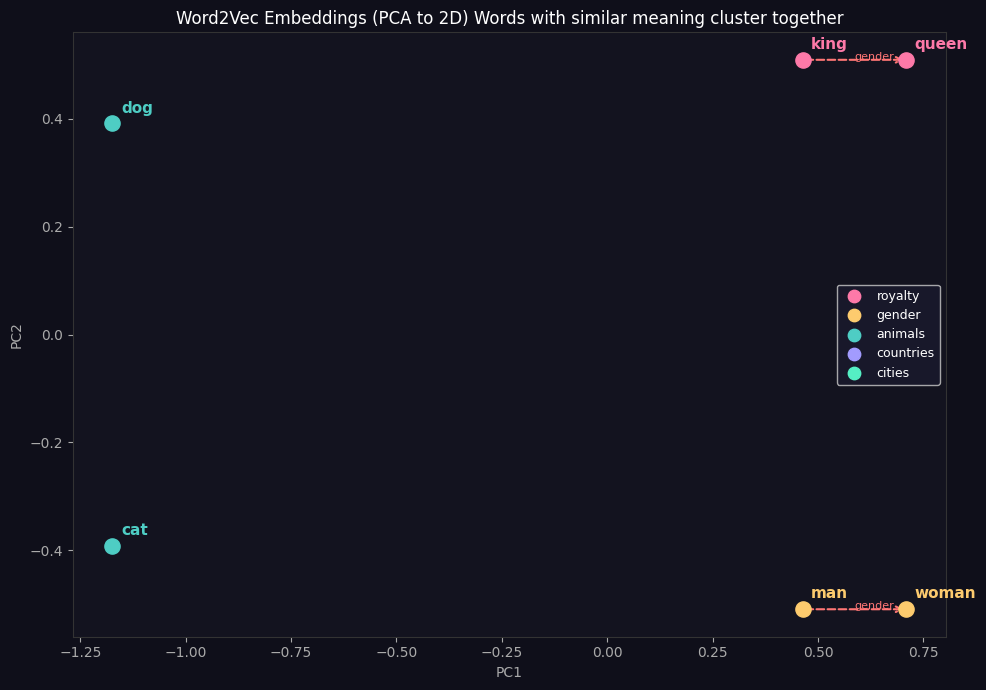

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ── Use Gensim for better embeddings on a richer corpus ──
try:
    from gensim.models import Word2Vec

    sentences = [
        ["king", "man", "royal", "throne", "power", "reign"],
        ["queen", "woman", "royal", "crown", "power", "reign"],
        ["man", "walks", "works", "strong", "father"],
        ["woman", "walks", "works", "strong", "mother"],
        ["cat", "pet", "meows", "fur", "whiskers"],
        ["dog", "pet", "barks", "fur", "tail"],
        ["paris", "france", "city", "eiffel"],
        ["berlin", "germany", "city", "wall"],
        ["london", "england", "city", "thames"],
        ["france", "europe", "country", "paris"],
        ["germany", "europe", "country", "berlin"],
        ["england", "europe", "country", "london"],
    ] * 50   # repeat for more training

    model = Word2Vec(sentences, vector_size=50, window=3, min_count=1,
                     sg=1, negative=5, epochs=100, seed=42)
    words_to_plot = ["king","queen","man","woman","cat","dog",
                     "france","germany","england","paris","berlin","london"]
    vectors = np.array([model.wv[w] for w in words_to_plot])
    print("Gensim model trained. Analogies:")
    try:
        result = model.wv.most_similar(positive=["king","woman"], negative=["man"], topn=3)
        print(f"  king - man + woman ≈ {result}")
    except: pass

except ImportError:
    # Fallback: synthetic embeddings arranged by hand for visualisation
    print("gensim not found — using synthetic embeddings for visualisation")
    words_to_plot = ["king","queen","man","woman","cat","dog"]
    vectors = np.array([
        [ 0.8,  0.3,  0.7, -0.2, 0.1],
        [ 0.75, 0.85, 0.7, -0.2, 0.1],
        [ 0.8,  0.3, -0.3,  0.2, 0.1],
        [ 0.75, 0.85,-0.3,  0.2, 0.1],
        [-0.7, -0.3,  0.2,  0.6, 0.5],
        [-0.7, -0.3,  0.2, -0.6, 0.5],
    ])

# ── PCA to 2D for visualisation ──
pca = PCA(n_components=2, random_state=42)
pts = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#0f0f1a'); ax.set_facecolor('#13131f')

# Colour by group
groups = {
    'royalty':   (['king','queen'], '#fd79a8'),
    'gender':    (['man','woman'], '#fdcb6e'),
    'animals':   (['cat','dog'], '#4ecdc4'),
    'countries': ([w for w in words_to_plot if w in ['france','germany','england']], '#a29bfe'),
    'cities':    ([w for w in words_to_plot if w in ['paris','berlin','london']], '#55efc4'),
}

for group_name, (group_words, color) in groups.items():
    for w in group_words:
        if w in words_to_plot:
            i = words_to_plot.index(w)
            ax.scatter(pts[i,0], pts[i,1], color=color, s=120, zorder=5)
            ax.annotate(w, (pts[i,0]+0.02, pts[i,1]+0.02), color=color,
                       fontsize=11, fontweight='bold')

# Draw analogy arrows: king - man + woman ≈ queen
def draw_arrow(ax, w1, w2, color='white', label=''):
    if w1 in words_to_plot and w2 in words_to_plot:
        i1, i2 = words_to_plot.index(w1), words_to_plot.index(w2)
        ax.annotate("", xy=pts[i2], xytext=pts[i1],
                    arrowprops=dict(arrowstyle="->", color=color, lw=1.5, linestyle='dashed'))
        if label:
            mid = (pts[i1]+pts[i2])/2
            ax.text(mid[0], mid[1], label, color=color, fontsize=8)

draw_arrow(ax, 'king', 'queen', '#ff7675', 'gender')
draw_arrow(ax, 'man',  'woman', '#ff7675', 'gender')

ax.set_title("Word2Vec Embeddings (PCA to 2D) Words with similar meaning cluster together", color='white', fontsize=12)
ax.set_xlabel("PC1", color='#aaa'); ax.set_ylabel("PC2", color='#aaa')
ax.tick_params(colors='#aaa')
for sp in ax.spines.values(): sp.set_color('#333')

# Legend
for name, (_, color) in groups.items():
    ax.scatter([], [], color=color, label=name, s=80)
ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)

plt.tight_layout()
plt.savefig('llm_basic/assets/02_w2v_geometry.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()


## 6. 📚 CBOW — Continuous Bag of Words

### Architecture
CBOW is the inverse of Skip-gram:
- **Input:** All context words (within window)
- **Output:** Predict the centre word

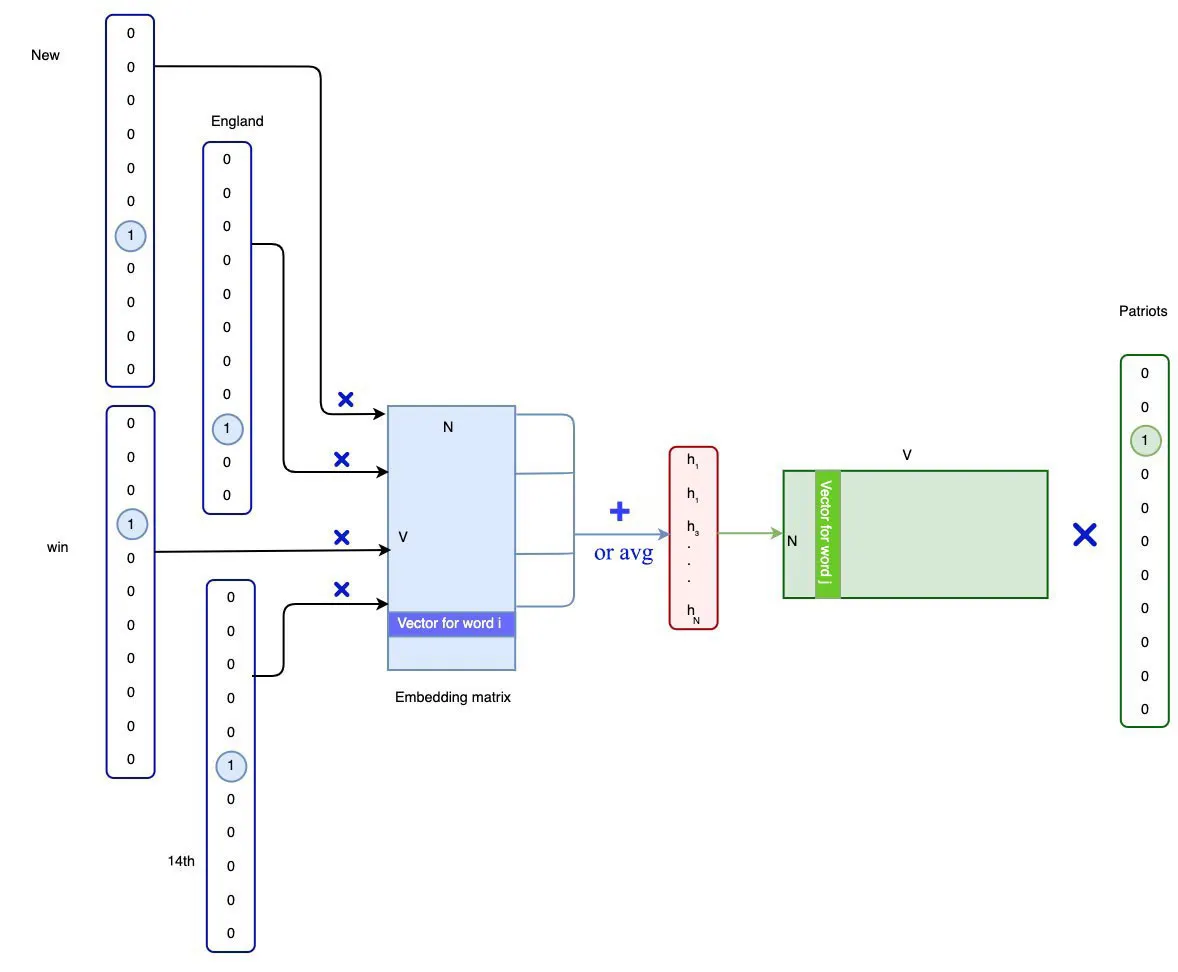

In [5]:
img_path = os.path.join(notebook_dir, r"assets\embeddings\cbow.webp")

# Load and show
try:
    img = Image.open(img_path)
    display(img)
except FileNotFoundError:
    print(f"Error: Could not find image at {img_path}")



### Forward Pass

**Step 1:** Look up embeddings for all context words and **average** them:
$$h = \frac{1}{|C|} \sum_{w \in C} W_{\text{in}}[:, w]$$

**Step 2:** Compute output scores (same as Skip-gram):
$$z = W_{\text{out}} \cdot h$$

**Step 3:** Softmax / Negative Sampling (same as Skip-gram)

### CBOW vs Skip-gram Comparison

| Property | CBOW | Skip-gram |
|---|---|---|
| **Input** | Context words → predict target | Target word → predict context |
| **Speed** | Faster (averages context) | Slower (multiple prediction targets per target) |
| **Frequent words** | Better — uses all context | ✅ What is used in practice? |
| **Rare words** | Weaker | Better (generates more training pairs) |
| **Large datasets** | Works well | Works well |
| **Common use** | When speed matters | **Preferred in most cases** |

### Why Skip-gram Generates More Data
For a target word with 4 context words (window=2):
- CBOW generates **1 training example**: (4 context words → 1 target)
- Skip-gram generates **4 training examples**: (target → each of 4 context words)

Skip-gram creates 4× more training signal from the same text, making it better for learning quality embeddings, especially for rare words that appear infrequently.


## 7. 🎯 Interview Q&A

**Q1: What does Word2Vec actually learn? Is it learning "meaning"?**
> Word2Vec learns word representations through a proxy task — predicting context words (or being predicted from context). It never explicitly learns "meaning." The key insight is that words appearing in similar contexts become similar in the learned vector space. This is powerful but also limited: "bank" (river bank) and "bank" (financial institution) will have the same vector, averaged over all its contexts.

---

**Q2: Explain Negative Sampling. Why is it necessary?**
> Without Negative Sampling, computing the softmax denominator requires summing over the entire vocabulary (50,000+ words) for every training step — computationally infeasible. Negative Sampling reformulates the problem: instead of "predict which of V words is the context", it asks "are these two words neighbours (1) or not (0)?". This binary classification only requires computing dot products for 1 positive + k (~5) negative words per step — a ~7000× speedup. The noise distribution uses frequency^0.75 to sample negatives, slightly favouring rare words.

---

**Q3: What is the noise distribution exponent 0.75 for?**
> Without modification, common words like "the" would dominate negative sampling (high frequency → high probability). But we already have plenty of signal about "the" — we want the model to also learn about rarer words. The 0.75 exponent compresses the distribution: rare words become relatively more likely to be sampled as negatives. It's empirically determined — values between 0.5 and 1.0 work; 0.75 was found best in the original paper.

---

**Q4: What are the two sets of embedding matrices in Word2Vec?**
> Word2Vec trains two embedding matrices: $W_{\text{in}}$ (input/target embeddings) and $W_{\text{out}}$ (output/context embeddings). Each word has two vectors — one as a "target" and one as a "context." After training, we typically use only $W_{\text{in}}$ as the word embeddings and discard $W_{\text{out}}$. Some implementations average both, which can give slight quality improvements.

---

**Q5: What are the limitations of Word2Vec?**
> (1) **Polysemy**: "bank" gets a single vector averaged across all meanings — no disambiguation. (2) **No subword understanding**: "running" and "runner" are unrelated unless both appear in training. Unknown words have no representation. (3) **Fixed context window**: Long-range dependencies (e.g., reference 50 words away) are not captured. (4) **Static embeddings**: Once trained, the vectors are fixed — they don't change based on sentence context. → These limitations are addressed by FastText (subwords) and ELMo/BERT (contextual).

---

**Q6: Why is the "king - man + woman ≈ queen" analogy possible?**
> This analogy works because Word2Vec encodes semantic relationships as consistent **vector offsets**. If "man" and "woman" differ by a gender vector $d_g$, and "king" and "queen" also differ by approximately $d_g$ in the embedding space, then arithmetically: king + (woman - man) ≈ queen. This parallelogram structure emerges purely from statistical co-occurrence patterns — not from any explicit encoding of gender. It's a beautiful emergent property.
